In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv(r"C:\Users\Tanmayee\OneDrive\Documents\Personal\Inifinte Solutions\ID4302\transaction_anomalies_dataset.csv")
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Transaction_ID               1000 non-null   object 
 1   Transaction_Amount           1000 non-null   float64
 2   Transaction_Volume           1000 non-null   int64  
 3   Average_Transaction_Amount   1000 non-null   float64
 4   Frequency_of_Transactions    1000 non-null   int64  
 5   Time_Since_Last_Transaction  1000 non-null   int64  
 6   Day_of_Week                  1000 non-null   object 
 7   Time_of_Day                  1000 non-null   object 
 8   Age                          1000 non-null   int64  
 9   Gender                       1000 non-null   object 
 10  Income                       1000 non-null   int64  
 11  Account_Type                 1000 non-null   object 
dtypes: float64(2), int64(5), object(5)
memory usage: 93.9+ KB


In [3]:
# Summary statistics
print(data.describe())

       Transaction_Amount  Transaction_Volume  Average_Transaction_Amount  \
count         1000.000000         1000.000000                 1000.000000   
mean          1038.122511            2.498000                 1000.682506   
std            283.580055            1.115006                   20.632334   
min            849.024392            1.000000                  939.081423   
25%            966.028796            1.000000                  986.800556   
50%           1002.118678            3.000000                 1000.501902   
75%           1033.143657            3.000000                 1015.155595   
max           3227.459108            4.000000                 1073.154036   

       Frequency_of_Transactions  Time_Since_Last_Transaction          Age  \
count                1000.000000                  1000.000000  1000.000000   
mean                   12.078000                    15.341000    40.641000   
std                     4.245225                     8.361258    13.8199

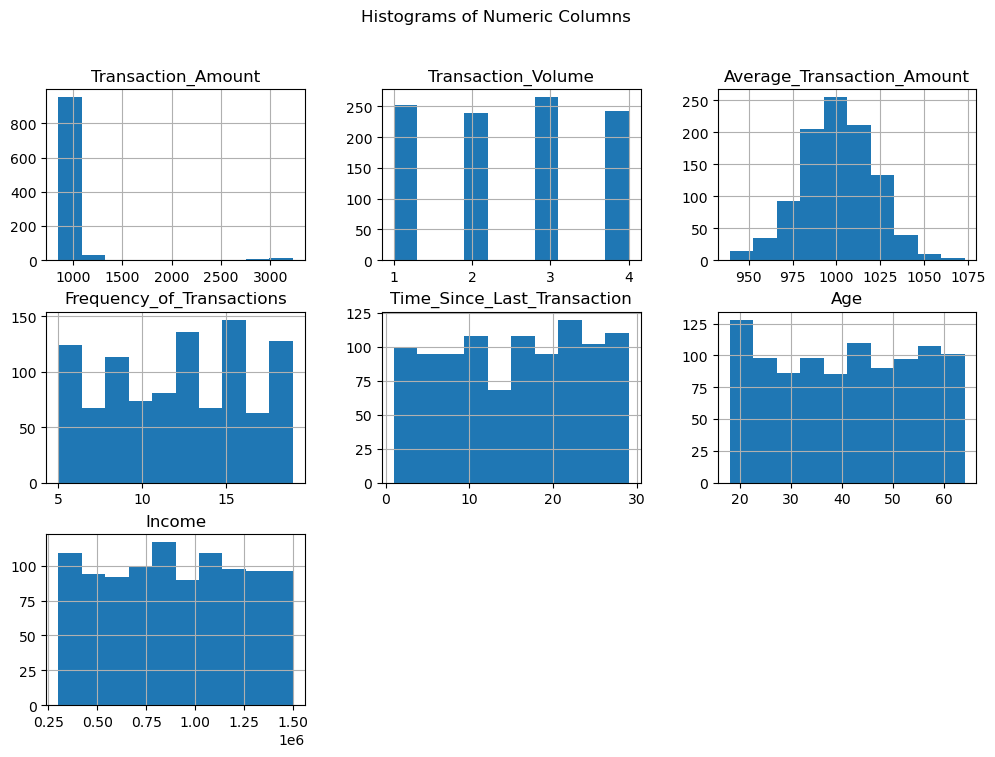

In [4]:
# Histograms for numeric columns
numeric_cols = ['Transaction_Amount', 'Transaction_Volume', 'Average_Transaction_Amount',
                'Frequency_of_Transactions', 'Time_Since_Last_Transaction', 'Age', 'Income']
data[numeric_cols].hist(figsize=(12, 8))
plt.suptitle('Histograms of Numeric Columns')
plt.show()

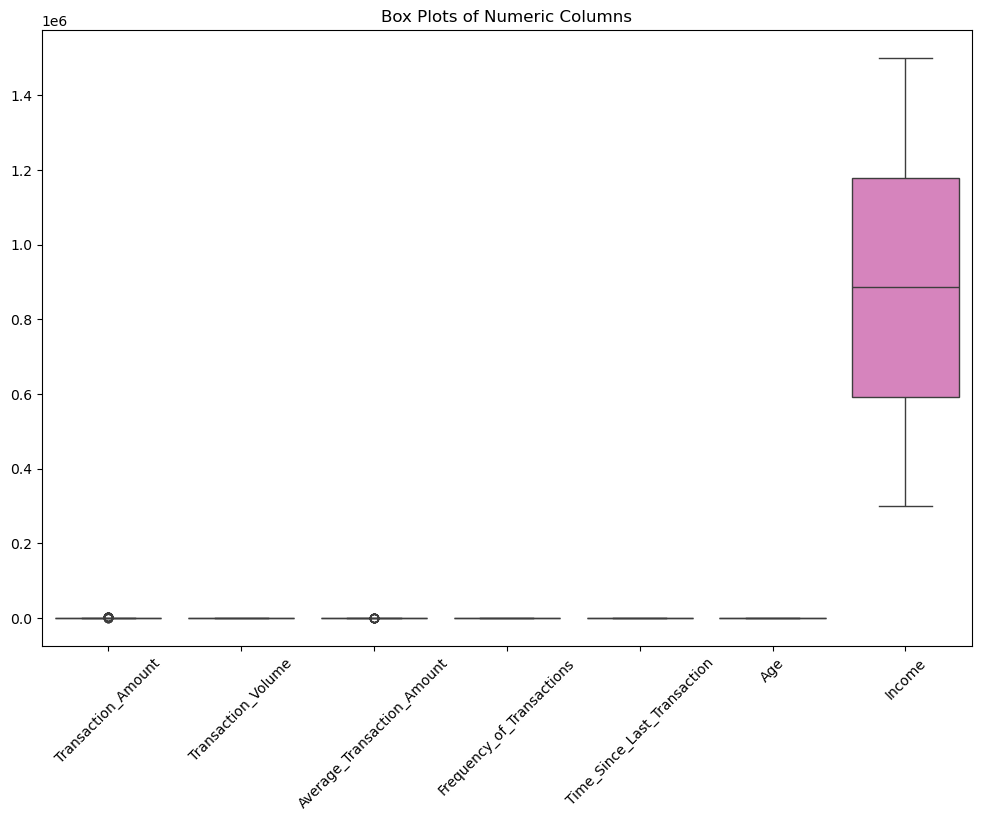

In [5]:
# Box plots for numeric columns
plt.figure(figsize=(12, 8))
sns.boxplot(data=data[numeric_cols])
plt.title('Box Plots of Numeric Columns')
plt.xticks(rotation=45)
plt.show()

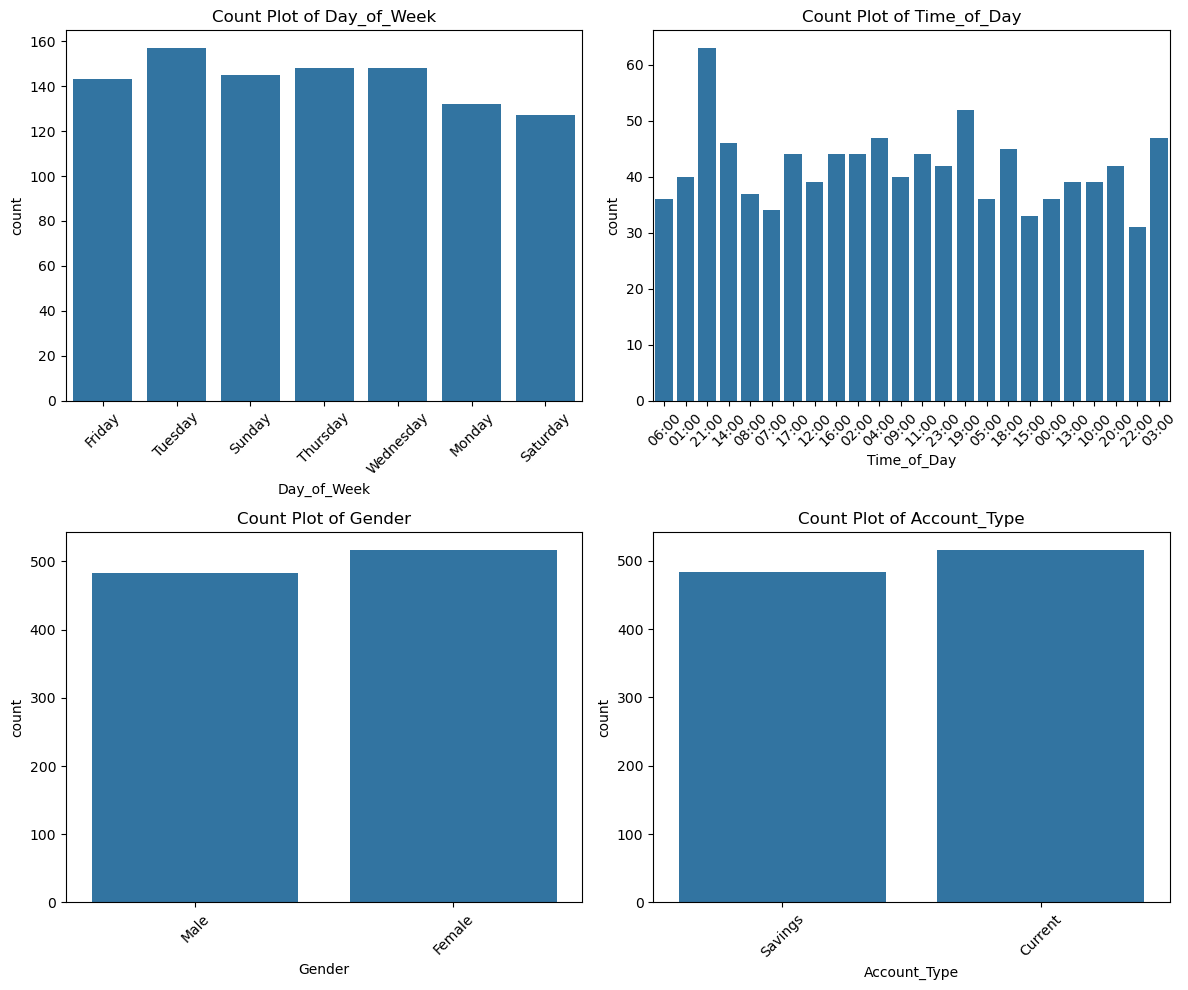

In [6]:
# Count plots for categorical columns
categorical_cols = ['Day_of_Week', 'Time_of_Day', 'Gender', 'Account_Type']
plt.figure(figsize=(12, 10))
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(2, 2, i)
    sns.countplot(data=data, x=col)
    plt.title(f'Count Plot of {col}')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

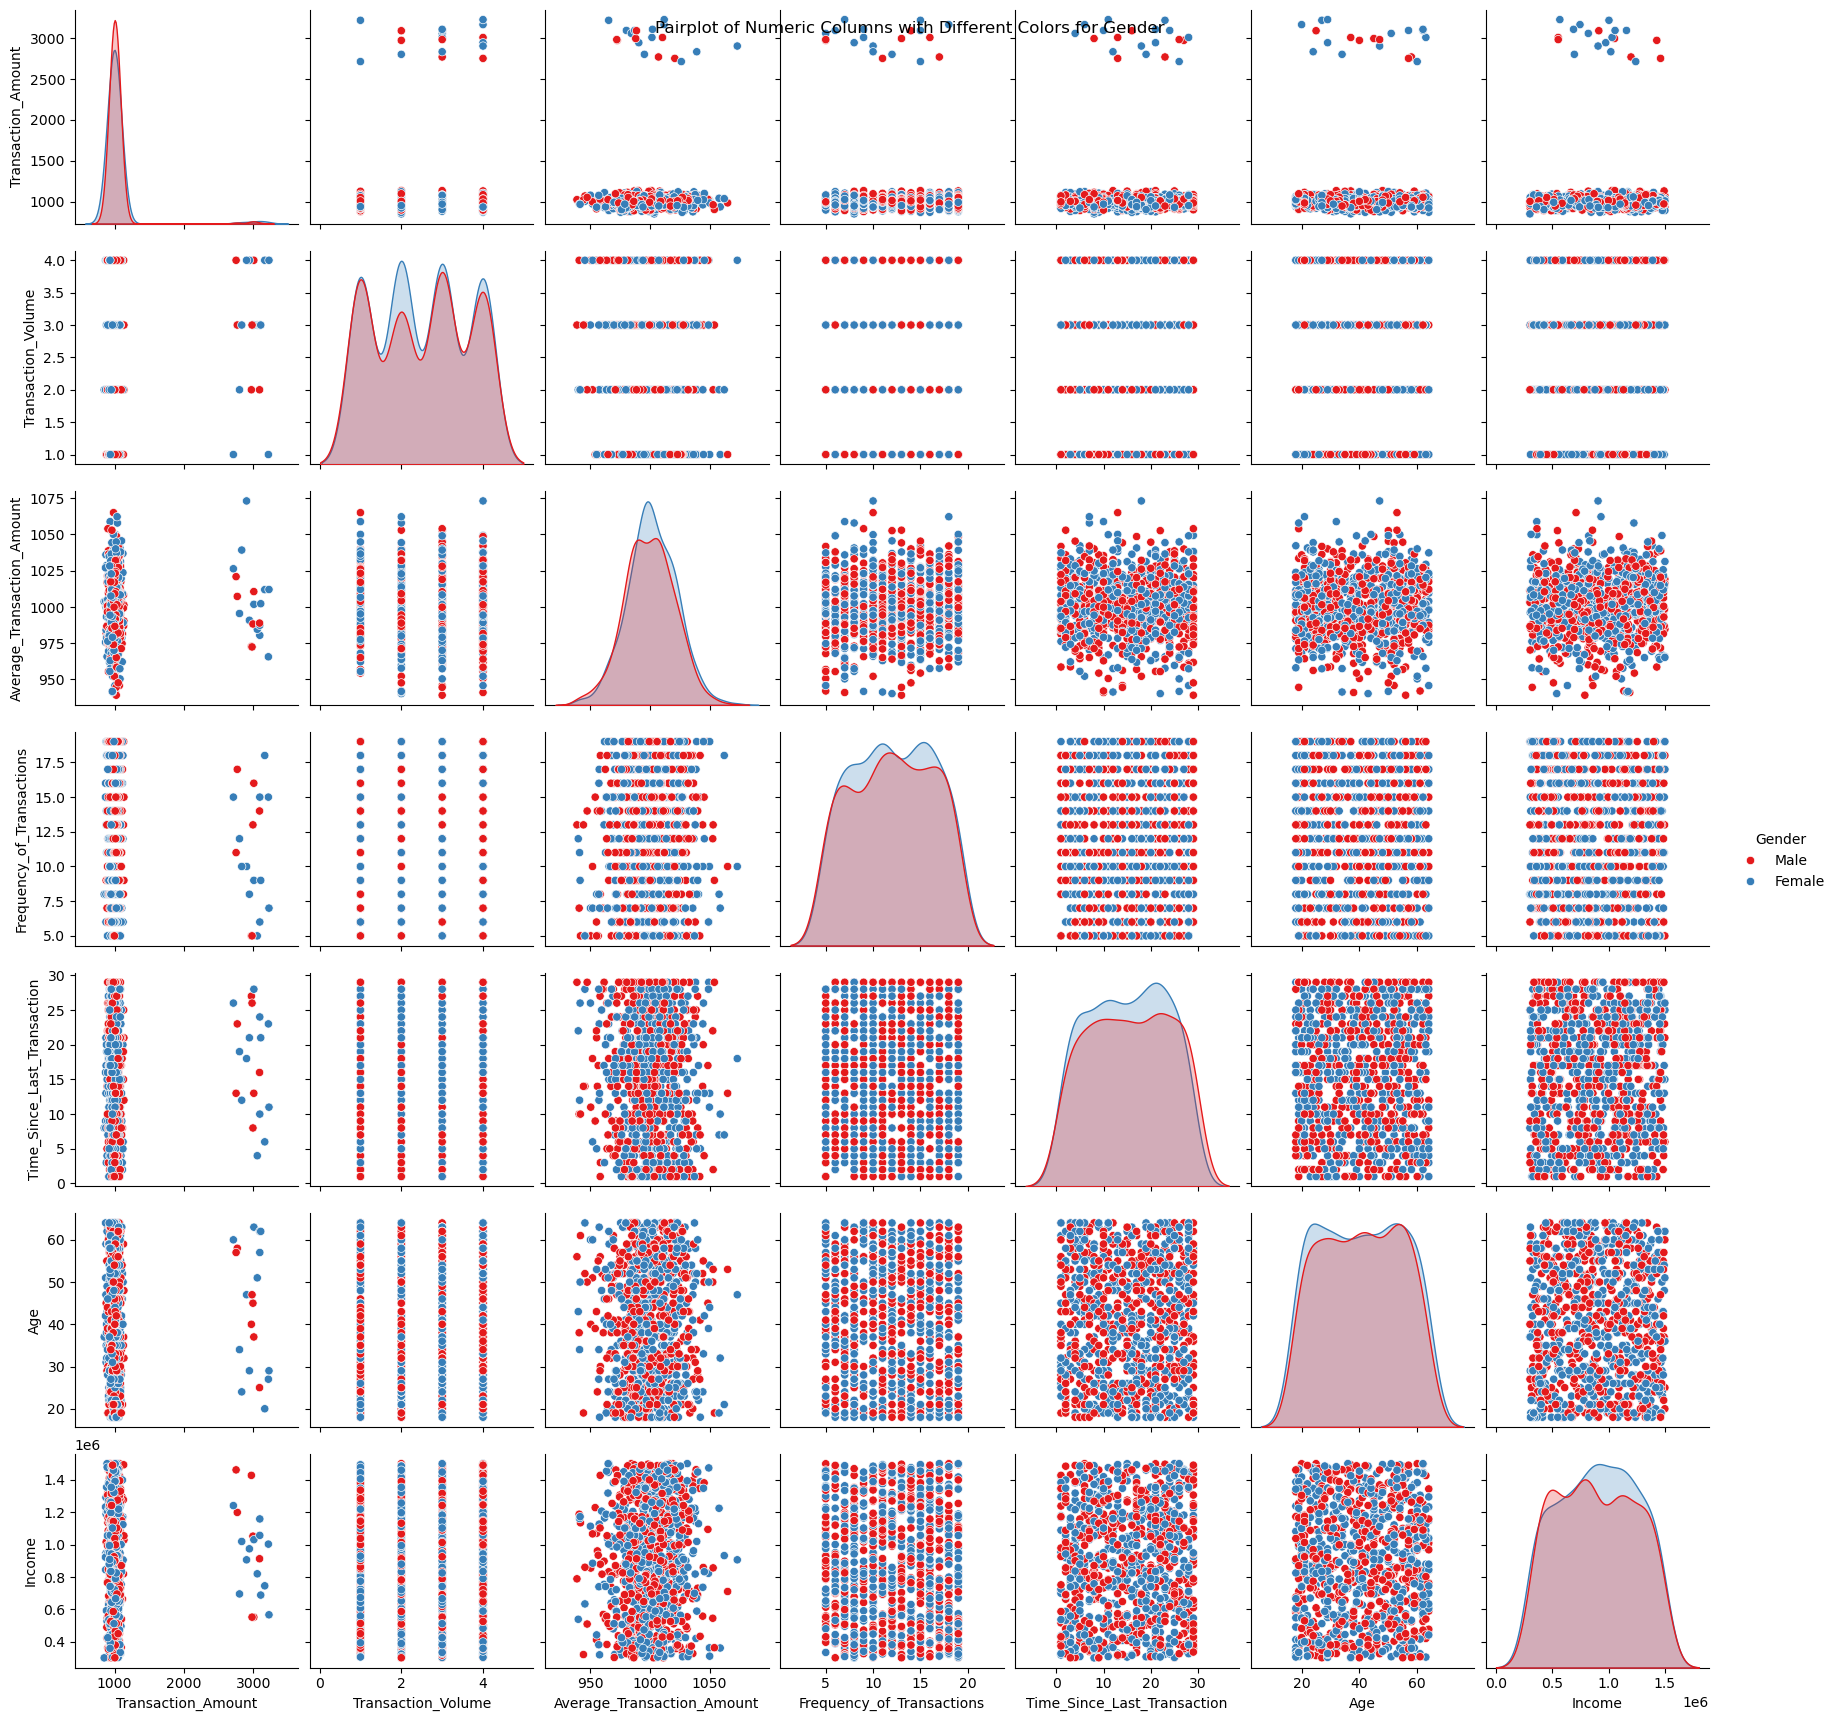

In [7]:
# Pairplot with different colors for each plot
sns.pairplot(data=data, vars=numeric_cols, hue='Gender', palette='Set1')
plt.suptitle('Pairplot of Numeric Columns with Different Colors for Gender')
plt.show()

In [8]:
# Check for null values in each column
null_counts = data.isnull().sum()

# Print the number of null values in each column
print("Null value counts:")
print(null_counts)

# Check if there are any null values in the DataFrame
if null_counts.sum() == 0:
    print("No null values found.")
else:
    print("Null values found.")

Null value counts:
Transaction_ID                 0
Transaction_Amount             0
Transaction_Volume             0
Average_Transaction_Amount     0
Frequency_of_Transactions      0
Time_Since_Last_Transaction    0
Day_of_Week                    0
Time_of_Day                    0
Age                            0
Gender                         0
Income                         0
Account_Type                   0
dtype: int64
No null values found.


In [9]:
from sklearn.preprocessing import LabelEncoder

# Define the columns to be label encoded
columns_to_encode = ['Day_of_Week', 'Time_of_Day', 'Gender', 'Account_Type']

# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Iterate through each column and perform label encoding
for column in columns_to_encode:
    data[column] = label_encoder.fit_transform(data[column])

# Display the encoded data
data


,Transaction_ID,Transaction_Amount,Transaction_Volume,Average_Transaction_Amount,Frequency_of_Transactions,Time_Since_Last_Transaction,Day_of_Week,Time_of_Day,Age,Gender,Income,Account_Type
0,TX0,1024.835708,3,997.234714,12,29,0,6,36,1,1436074,1
1,TX1,1013.952065,4,1020.210306,7,22,0,1,41,0,627069,1
2,TX2,970.956093,1,989.496604,5,12,5,21,61,1,786232,1
3,TX3,1040.822254,2,969.522480,16,28,3,14,61,1,619030,1
4,TX4,998.777241,1,1007.111026,7,7,0,8,56,0,649457,1
...,...,...,...,...,...,...,...,...,...,...,...,...
995,TX995,901.138758,3,976.363229,17,19,1,5,46,0,424746,1
996,TX996,928.962516,4,1028.292292,10,25,6,9,58,0,908278,0
997,TX997,950.921600,2,1022.823424,13,28,0,2,58,0,1353498,0
998,TX998,933.291962,4,994.325450,10,8,5,4,58,0,359072,1


In [10]:
from sklearn.model_selection import train_test_split

# Define features and target variable
X = data.drop(columns=['Transaction_ID', 'Account_Type'])  # Features
y = data['Account_Type']  # Target variable

# Split the data into train and test sets
test_size = 0.2
random_state = 42
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)

# Print the shape of the resulting sets
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)


Shape of X_train: (800, 10)
Shape of X_test: (200, 10)
Shape of y_train: (800,)
Shape of y_test: (200,)


In [11]:
from sklearn.ensemble import IsolationForest

# Define and train the Isolation Forest model
isolation_forest = IsolationForest(random_state=random_state)
isolation_forest.fit(X_train)

# Predict outliers in the training set
outliers_train = isolation_forest.predict(X_train)

# Predict outliers in the test set
outliers_test = isolation_forest.predict(X_test)

# Convert predictions to binary labels (1 for inliers, -1 for outliers)
outliers_train = [1 if x == 1 else 0 for x in outliers_train]
outliers_test = [1 if x == 1 else 0 for x in outliers_test]

# Print the number of outliers detected in the training and test sets
print("Number of outliers in the training set:", sum(outliers_train))
print("Number of outliers in the test set:", sum(outliers_test))


Number of outliers in the training set: 336
Number of outliers in the test set: 84


In [13]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# Calculate precision, recall, and F1-score for the training set
accuracy_train_iso = accuracy_score(y_train, outliers_train)
precision_train_iso = precision_score(y_train, outliers_train)
recall_train_iso = recall_score(y_train, outliers_train)
f1_train_iso = f1_score(y_train, outliers_train)

# Calculate precision, recall, and F1-score for the test set
accuracy_test_iso = accuracy_score(y_test, outliers_test)
precision_test_iso = precision_score(y_test, outliers_test)
recall_test_iso = recall_score(y_test, outliers_test)
f1_test_iso = f1_score(y_test, outliers_test)

# Print the evaluation metrics for the training set
print("Evaluation metrics for the training set:")
print("Accuracy score for the training set:", accuracy_train_iso)
print("Precision:", precision_train_iso)
print("Recall:", recall_train_iso)
print("F1-score:", f1_train_iso)

# Print the evaluation metrics for the test set
print("\nEvaluation metrics for the test set:")
print("Accuracy score for the test set:", accuracy_test_iso)
print("Precision:", precision_test_iso)
print("Recall:", recall_test_iso)
print("F1-score:", f1_test_iso)


Evaluation metrics for the training set:
Accuracy score for the training set: 0.51
Precision: 0.4880952380952381
Recall: 0.4270833333333333
F1-score: 0.45555555555555555

Evaluation metrics for the test set:
Accuracy score for the test set: 0.51
Precision: 0.5119047619047619
Recall: 0.43
F1-score: 0.4673913043478261
